# Synthetic SVXY: SVXY_synth-HALFx

#### **MScFE 690 Capstone -Group 17843**

**Authors**: Edgar NAVA-edgar.nava@grovwm.com & Celestin NYANDWI-celestinnyandwi48@gmail.com

The idea is to obtain a **semi-synthetic SVXY with a consistent -0.5x daily exposure** for our Capstone. This time we work backwards. We preserve the actual SVXY OHLC from February 28, 2018 onward and reconstruct the earlier -1x period using half of the daily movements of the reference series corrected for Volmageddon.

In our methodology we exclude February 5 from the regression, since is the date of volmageddon, but use its actual closing values to estimate February 6. The regression and the event correction are the same as in the ONEx notebook. The change here is the direction of reconstruction and the daily exposure multiplier.

Everything is read from and saved to the **current working directory**. The inputs are `SVXY_data.csv` and `SPVIXSTR.xlsx`. If a library is missing, run `%pip install pandas numpy matplotlib openpyxl`.

This notebook creates one output file: `SVXY_synth-HALFx.csv`, with `Date`, `Open`, `High`, `Low` and `Close`.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

DATA_DIR = Path.cwd()
SVXY_FILE = DATA_DIR / "SVXY_data.csv"
INDEX_FILE = DATA_DIR / "SPVIXSTR.xlsx"

FIT_END = pd.Timestamp("2018-02-02")
EVENT_BASE = pd.Timestamp("2018-02-05")
EVENT_DATE = pd.Timestamp("2018-02-06")
LAST_ONEX = pd.Timestamp("2018-02-27")
FIRST_HALFX = pd.Timestamp("2018-02-28")

missing = [p.name for p in [SVXY_FILE, INDEX_FILE] if not p.is_file()]
if missing:
    raise FileNotFoundError(
        f"Missing {missing} in {DATA_DIR}. Open this notebook in Data Retreived "
        "with SVXY_data.csv and SPVIXSTR.xlsx in the same working directory."
    )

plt.rcParams.update({
    "figure.figsize": (12, 5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.20, "font.size": 10,
})
ACTUAL_COLOR = "#657786"
SYNTH_COLOR = "#3B67B6"
EVENT_COLOR = "#BD5D36"

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

input_hashes = {p.name: sha256_file(p) for p in [SVXY_FILE, INDEX_FILE]}

def validate_prices(series, label):
    if series.empty:
        raise ValueError(f"{label}: no observations.")
    if series.index.has_duplicates or series.index.isna().any():
        raise ValueError(f"{label}: missing or duplicate dates. Check the source.")
    values = series.to_numpy(dtype=float)
    if not np.isfinite(values).all() or (values <= 0).any():
        raise ValueError(f"{label}: missing, non-finite or non-positive prices.")

OHLC_COLUMNS = ["Open", "High", "Low", "Close"]

def validate_ohlc(frame, label):
    for column in OHLC_COLUMNS:
        validate_prices(frame[column], f"{label} {column}")
    invalid = (
        (frame["Low"] > frame[["Open", "Close"]].min(axis=1))
        | (frame["High"] < frame[["Open", "Close"]].max(axis=1))
        | (frame["High"] < frame["Low"])
    )
    if invalid.any():
        raise ValueError(f"{label}: inconsistent OHLC on {frame.index[invalid].tolist()}")

print("Working directory:", DATA_DIR)
print("Inputs found:", SVXY_FILE.name, "and", INDEX_FILE.name)

Working directory: /Users/edgarnava/Dropbox/AI/WorldQuant University/10 26:09 MScFE 690 Capstone Project/Python Codes/1 - Data Retreived and Synth SVXY
Inputs found: SVXY_data.csv and SPVIXSTR.xlsx


### 1. SVXY discontinuity and the change from -1x to -0.5x

See notebook SVXY_synth-ONEx.ipynb

In [2]:
svxy_raw = pd.read_csv(SVXY_FILE)
svxy_raw.columns = svxy_raw.columns.str.strip()
if not {"Date", *OHLC_COLUMNS}.issubset(svxy_raw.columns):
    raise ValueError("SVXY_data.csv must contain Date, Open, High, Low and Close.")
svxy_raw["Date"] = pd.to_datetime(svxy_raw["Date"], errors="raise").dt.normalize()
for column in OHLC_COLUMNS:
    svxy_raw[column] = pd.to_numeric(svxy_raw[column], errors="raise")
actual_ohlc = svxy_raw.set_index("Date")[OHLC_COLUMNS].sort_index()
validate_ohlc(actual_ohlc, "Actual SVXY")
svxy = actual_ohlc["Close"].rename("SVXY_actual_Close")
for date in [FIT_END, EVENT_BASE, EVENT_DATE, LAST_ONEX, FIRST_HALFX]:
    if date not in svxy.index:
        raise ValueError(f"Required SVXY date missing: {date.date()}")

actual_returns = svxy.pct_change(fill_method=None)

### 2. SPVIXSTR index.

See notebook SVXY_synth-ONEx.ipynb

In [3]:
# The supplied Excel has its title in row 1 and column headers in row 2.
index_raw = pd.read_excel(INDEX_FILE, sheet_name="Sheet1", header=1, usecols="A:B")
index_raw.columns = index_raw.columns.str.strip()
if not {"Date", "Price"}.issubset(index_raw.columns):
    raise ValueError("SPVIXSTR.xlsx must have Date and Price in columns A:B, header row 2.")
index_raw["Date"] = pd.to_datetime(index_raw["Date"], errors="raise").dt.normalize()
index_raw["Price"] = pd.to_numeric(index_raw["Price"], errors="raise")
spvixstr = index_raw.set_index("Date")["Price"].sort_index().rename("SPVIXSTR_Price")
validate_prices(spvixstr, "SPVIXSTR")

# Source diagnostics only: no adjustment is made to these index observations.
index_source_returns = spvixstr.pct_change(fill_method=None)
large_index_jumps = index_source_returns.loc[index_source_returns.abs() > 5]
print(f"SPVIXSTR: {len(spvixstr):,} prices, {spvixstr.index.min().date()} to {spvixstr.index.max().date()}")
if not large_index_jumps.empty:
    print("Index level discontinuities above 500% (outside the model window if after Feb 6, 2018):")
    display(pd.DataFrame({"Price": spvixstr.loc[large_index_jumps.index],
                          "Mechanical_change_pct": 100 * large_index_jumps}))
    if (large_index_jumps.index <= EVENT_DATE).any():
        raise ValueError("An index discontinuity enters the model window. Resolve it first.")

aligned_prices = pd.DataFrame({"SVXY": svxy, "SPVIXSTR": spvixstr.reindex(svxy.index)})
common_start = max(svxy.index.min(), spvixstr.index.min())
needed_index = aligned_prices.loc[common_start:EVENT_DATE, "SPVIXSTR"]
if needed_index.isna().any():
    raise ValueError("SPVIXSTR is missing on an SVXY date needed for calibration or reconstruction.")

# Prices are aligned BEFORE percentage changes are computed.
aligned_returns = aligned_prices.pct_change(fill_method=None)
fit_data = aligned_returns.loc[:FIT_END].dropna(subset=["SVXY", "SPVIXSTR"]).copy()
if len(fit_data) < 30 or fit_data["SPVIXSTR"].std() == 0:
    raise ValueError("Insufficient usable variation for the regression.")
if EVENT_BASE in fit_data.index or EVENT_DATE in fit_data.index:
    raise AssertionError("Event dates must not enter the regression.")

SPVIXSTR: 3,452 prices, 2012-12-27 to 2026-09-18
Index level discontinuities above 500% (outside the model window if after Feb 6, 2018):


,Price,Mechanical_change_pct
Date,,
2024-08-08,17728.78,913754.639175


#### The regression and the R²
See notebook SVXY_synth-ONEx.ipynb

In [4]:
def fit_daily_ols(data):
    x = data["SPVIXSTR"].to_numpy(dtype=float)
    y = data["SVXY"].to_numpy(dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    alpha_, beta_ = np.linalg.lstsq(design, y, rcond=None)[0]
    fitted_ = alpha_ + beta_ * x
    sst = np.sum((y - y.mean()) ** 2)
    if sst <= 0:
        raise ValueError("SVXY returns have no variation.")
    r2_ = 1 - np.sum((y - fitted_) ** 2) / sst
    rmse_ = np.sqrt(np.mean((y - fitted_) ** 2))
    return float(alpha_), float(beta_), float(r2_), float(rmse_), fitted_

alpha, beta, r_squared, rmse, fitted = fit_daily_ols(fit_data)
fit_data["Fitted_SVXY_return"] = fitted

train = fit_data.loc[:"2016-12-31"]
test = fit_data.loc["2017-01-01":"2017-12-31"]
holdout = None
if len(train) >= 30 and len(test) >= 2:
    a_train, b_train, _, _, _ = fit_daily_ols(train)
    test_prediction = a_train + b_train * test["SPVIXSTR"]
    test_sst = ((test["SVXY"] - test["SVXY"].mean()) ** 2).sum()
    if test_sst <= 0:
        raise ValueError("The holdout returns have no variation.")
    holdout = {
        "training_observations": len(train), "test_observations": len(test),
        "test_year": 2017,
        "r_squared": float(1 - ((test["SVXY"] - test_prediction) ** 2).sum() / test_sst),
        "rmse": float(np.sqrt(((test["SVXY"] - test_prediction) ** 2).mean())),
    }



### 3. Correct Volmageddon in the -1x reference

We first build the corrected -1x reference needed for the backwards calculation. These reference prices are intermediate values, not the final HALFx prices. So far, we have a daily relationship estimated without February 5. Now we use the actual SPVIXSTR change **from February 5 to February 6**, and insert it into that same regression:

$$\widehat r_6=\alpha+\beta\left(\frac{I_6}{I_5}-1\right),\qquad
\widehat P_6=P^{actual}_5(1+\widehat r_6).$$

The correction factor is:

$$corr\_f=\frac{\widehat P_6}{P^{actual}_6}.$$

We then multiply each actual SVXY closing price from **February 6 through February 27, inclusive**, by `corr_f`. Before February 6 we keep the actual SVXY closing prices.

The rationale is to replace the February 5-to-6 return with the return implied by the pre-event relationship. A constant multiplier preserves every actual daily return from February 7 through February 27. February 5's actual decline remains in the series; this construction does not erase the whole episode or establish what SVXY would truly have done without Volmageddon.

For reference, the supplied data should give a hypothetical February 6 close near **175.920985**, compared with the actual **24.48**, and `corr_f` near **7.186315**.

,Calculation,Value
0,SPVIXSTR close Feb 5,110.370000
1,SPVIXSTR close Feb 6,81.730000
2,SPVIXSTR change Feb 6 (%),-25.949080
3,Estimated SVXY change Feb 6 (%),22.473535
4,Actual SVXY close Feb 5,143.639999
5,Actual SVXY close Feb 6,24.480000
6,Estimated SVXY close Feb 6,175.920985
7,corr_f,7.186315
8,Corrected SVXY close Feb 27,178.076887


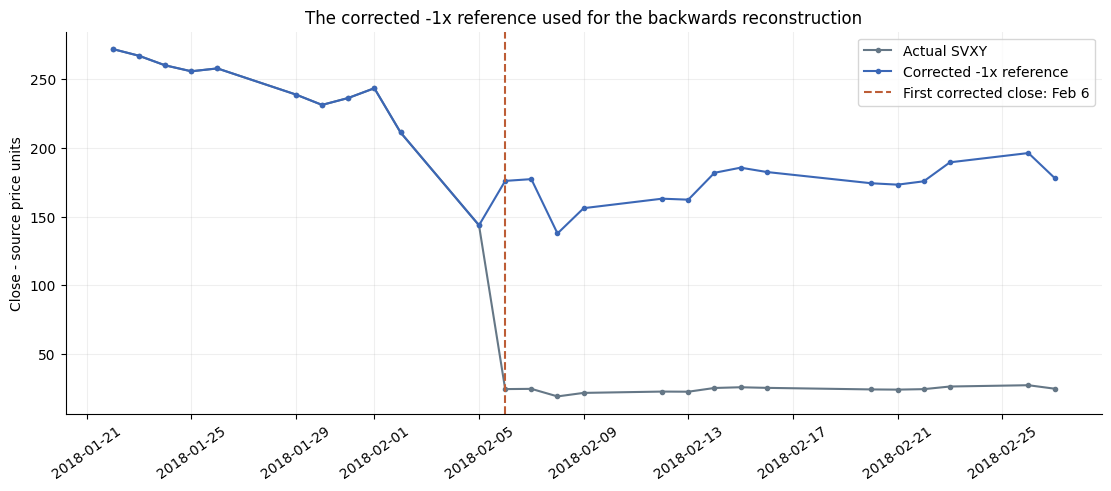

In [5]:
index_return_feb6 = float(aligned_returns.loc[EVENT_DATE, "SPVIXSTR"])
estimated_return_feb6 = float(alpha + beta * index_return_feb6)
if not np.isfinite(estimated_return_feb6) or estimated_return_feb6 <= -1:
    raise ValueError("The model implies a non-positive February 6 close.")

estimated_close_feb6 = float(svxy.loc[EVENT_BASE] * (1 + estimated_return_feb6))
corr_f = estimated_close_feb6 / float(svxy.loc[EVENT_DATE])
if not np.isfinite(corr_f) or corr_f <= 0:
    raise ValueError("Invalid correction factor.")

event_adjusted = svxy.loc[:LAST_ONEX].copy().rename("SVXY_event_adjusted_Close")
event_adjusted.loc[EVENT_DATE:LAST_ONEX] *= corr_f

event_summary = pd.DataFrame({
    "Calculation": ["SPVIXSTR close Feb 5", "SPVIXSTR close Feb 6",
                    "SPVIXSTR change Feb 6 (%)", "Estimated SVXY change Feb 6 (%)",
                    "Actual SVXY close Feb 5", "Actual SVXY close Feb 6",
                    "Estimated SVXY close Feb 6", "corr_f",
                    "Corrected SVXY close Feb 27"],
    "Value": [aligned_prices.loc[EVENT_BASE, "SPVIXSTR"],
              aligned_prices.loc[EVENT_DATE, "SPVIXSTR"],
              100*index_return_feb6, 100*estimated_return_feb6,
              svxy.loc[EVENT_BASE], svxy.loc[EVENT_DATE],
              estimated_close_feb6, corr_f, event_adjusted.loc[LAST_ONEX]],
})
display(event_summary.round({"Value": 9}))

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
observed_window = svxy.loc["2018-01-22":LAST_ONEX]
adjusted_window = event_adjusted.loc["2018-01-22":LAST_ONEX]
ax.plot(observed_window.index, observed_window, color=ACTUAL_COLOR, marker="o",
        markersize=3, label="Actual SVXY")
ax.plot(adjusted_window.index, adjusted_window, color=SYNTH_COLOR, marker="o",
        markersize=3, label="Corrected -1x reference")
ax.axvline(EVENT_DATE, color=EVENT_COLOR, linestyle="--", label="First corrected close: Feb 6")
ax.set(title="The corrected -1x reference used for the backwards reconstruction",
       ylabel="Close - source price units")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.show()

### 4. Reconstruct the Close backwards at half the daily exposure

From February 28, 2018 onward, SVXY already has the -0.5x daily objective that we want. We keep those prices as they are. To connect the previous history to them, we set the **February 27 synthetic Close equal to its actual Close**, 24.780001 in the supplied data. This also preserves the actual return from February 27 to February 28.

Let $B_t$ be the corrected -1x reference Close from Section 3, and let $S_t$ be the HALFx Close. Through February 27, we want:

$$r^{HALF}_t=\frac12\left(\frac{B_t}{B_{t-1}}-1\right).$$

Working backwards means solving the usual daily compounding formula for the previous Close:

$$S_{t-1}=\frac{S_t}{1+r^{HALF}_t}.$$

We start at February 27 and apply this division one trading day at a time until the first date. We halve **simple daily percentage changes**, not price levels. We also do not negate a return or halve the inverse return when moving backwards.

The rationale is to preserve the actual -0.5x period and reconstruct an earlier period with comparable daily exposure. February 5's decline remains, with half its percentage movement. On February 6 we use half the model-implied -1x return, approximately **+11.236768%**. The regression itself is not reversed.

#### The correction factor towards the earlier dates

We can also express the Volmageddon adjustment as a factor applied to an otherwise identical backwards HALF reconstruction that uses the actual, uncorrected February 6 return. Let that uncorrected reconstruction be $U_t$. Both versions have the same February 27 anchor and coincide from February 6 onward. At February 5:

$$U_5=\frac{S_6}{1+0.5r^{actual}_6},\qquad
S_5=\frac{S_6}{1+0.5\widehat r_6}.$$

Therefore:

$$corr\_f_{backward}=\frac{S_5}{U_5}
=\frac{1+0.5r^{actual}_6}{1+0.5\widehat r_6}.$$

With the supplied data this factor is approximately **0.526096762**. Multiplying $U_t$ by this factor for every date through February 5 gives the corrected HALF closes. The backwards recursion already includes this correction, so we do not apply the factor again. It is not simply $1/corr\_f$, because here the daily exposure has also been halved.

In [6]:
reference_close = event_adjusted.rename("Corrected_ONEx_reference_Close")
reference_returns = reference_close.pct_change(fill_method=None)
half_returns = 0.5 * reference_returns

def reconstruct_backwards(daily_returns, anchor_close):
    growth = 1 + daily_returns.iloc[1:]
    if not np.isfinite(growth).all() or (growth <= 0).any():
        raise ValueError("The backwards reconstruction has invalid daily growth.")
    result = pd.Series(index=daily_returns.index, dtype=float)
    result.iloc[-1] = anchor_close
    for position in range(len(result) - 1, 0, -1):
        result.iloc[position - 1] = result.iloc[position] / growth.iloc[position - 1]
    return result

anchor_close = float(svxy.loc[LAST_ONEX])
halfx = svxy.copy().rename("SVXY_synth-HALFx")
halfx.loc[:LAST_ONEX] = reconstruct_backwards(half_returns, anchor_close)
validate_prices(halfx, "SVXY_synth-HALFx")
halfx_returns = halfx.pct_change(fill_method=None)

# An equivalent, uncorrected HALF calculation makes the backwards factor explicit.
uncorrected_half = reconstruct_backwards(0.5 * actual_returns.loc[:LAST_ONEX], anchor_close)
corr_f_backward = float(
    (1 + 0.5 * actual_returns.loc[EVENT_DATE]) / (1 + 0.5 * estimated_return_feb6)
)
np.testing.assert_allclose(
    halfx.loc[:EVENT_BASE], uncorrected_half.loc[:EVENT_BASE] * corr_f_backward, rtol=1e-12
)
np.testing.assert_allclose(
    halfx.loc[EVENT_DATE:LAST_ONEX], uncorrected_half.loc[EVENT_DATE:LAST_ONEX], rtol=1e-12
)

print(f"February 27 closing anchor: {anchor_close:.9f}")
print(f"Backwards HALF event correction factor: {corr_f_backward:.12f}")
print(f"HALFx February 6 return: {100*halfx_returns.loc[EVENT_DATE]:.6f}%")
example_dates = pd.to_datetime(["2018-02-02", "2018-02-05", "2018-02-06", "2018-02-27", "2018-02-28"])
display(pd.DataFrame({
    "Actual_Close": svxy, "HALFx_Close": halfx,
    "Actual_daily_change_pct": 100*actual_returns,
    "HALFx_daily_change_pct": 100*halfx_returns,
}).loc[example_dates].round(6))

February 27 closing anchor: 24.780001000
Backwards HALF event correction factor: 0.526096761969
HALFx February 6 return: 11.236768%


,Actual_Close,HALFx_Close,Actual_daily_change_pct,HALFx_daily_change_pct
2018-02-02,211.199997,25.985968,-13.207857,-6.603929
2018-02-05,143.639999,21.829690,-31.988636,-15.994318
2018-02-06,24.480000,24.282641,-82.957393,11.236768
2018-02-27,24.780001,24.780001,-9.230762,-4.615381
2018-02-28,24.459999,24.459999,-1.291372,-1.291372


#### Check the backwards reconstruction and the connection to real SVXY

We check that the earlier HALFx returns are half the corrected -1x reference returns. The February 27 Close is the actual anchor, and the February 28 return is the actual SVXY return. From February 28 onward, the series uses the actual data.

The February 27 **Open, High and Low still need to be reconstructed** at half exposure; only its Close is the anchor. We build those prices in the next section.

The comparison below shows the full history and a closer look at the event and change in exposure. The R² above measures the original regression; the HALF construction follows the stated return-scaling rule.

Close checks passed, including the February 27 -> February 28 connection.


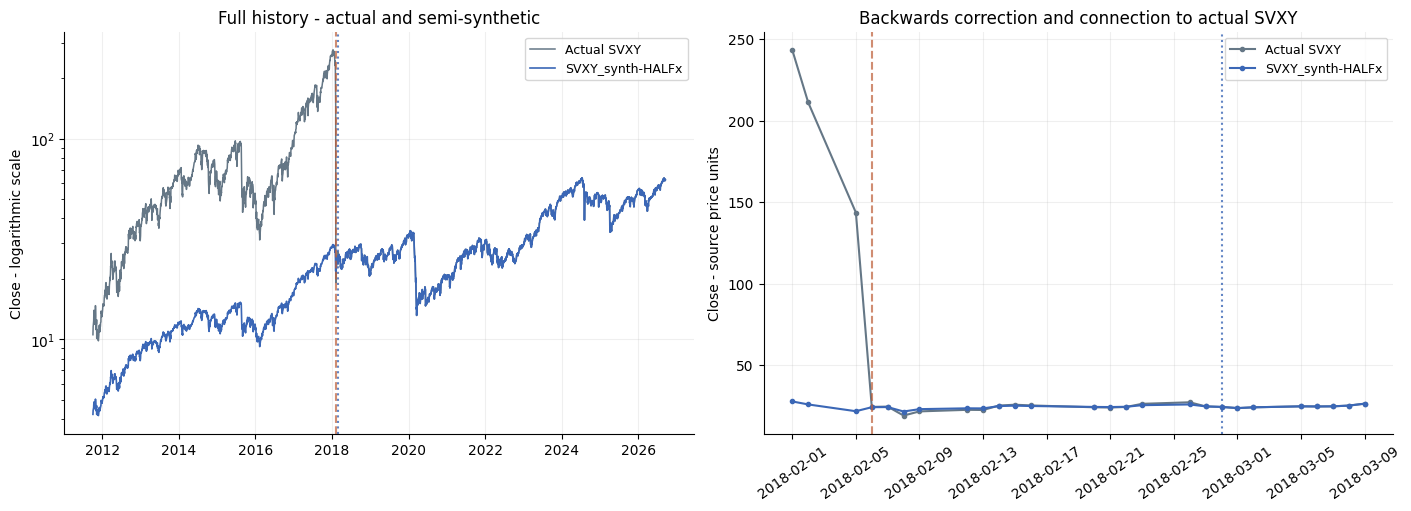

In [7]:
pd.testing.assert_index_equal(halfx.index, svxy.index)
np.testing.assert_array_equal(halfx.loc[LAST_ONEX:], svxy.loc[LAST_ONEX:])
np.testing.assert_allclose(
    halfx_returns.loc[reference_close.index[1:]], half_returns.iloc[1:], rtol=1e-12, atol=1e-12
)
np.testing.assert_allclose(halfx_returns.loc[EVENT_DATE], 0.5*estimated_return_feb6, atol=1e-12)
np.testing.assert_allclose(halfx_returns.loc[FIRST_HALFX:], actual_returns.loc[FIRST_HALFX:], atol=1e-12)

# Forward compounding independently checks the backwards indexing and anchor.
forward_check = halfx.iloc[0] * (1 + half_returns.iloc[1:]).cumprod()
np.testing.assert_allclose(forward_check, halfx.loc[forward_check.index], rtol=1e-12)
print("Close checks passed, including the February 27 -> February 28 connection.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].plot(svxy.index, svxy, color=ACTUAL_COLOR, linewidth=1.1, label="Actual SVXY")
axes[0].plot(halfx.index, halfx, color=SYNTH_COLOR, linewidth=1.2, label="SVXY_synth-HALFx")
axes[0].set_yscale("log")
axes[0].set(title="Full history - actual and semi-synthetic", ylabel="Close - logarithmic scale")
zoom = pd.DataFrame({"Actual SVXY": svxy, "SVXY_synth-HALFx": halfx}).loc["2018-02-01":"2018-03-09"]
axes[1].plot(zoom.index, zoom["Actual SVXY"], color=ACTUAL_COLOR, marker="o", markersize=3, label="Actual SVXY")
axes[1].plot(zoom.index, zoom["SVXY_synth-HALFx"], color=SYNTH_COLOR, marker="o", markersize=3, label="SVXY_synth-HALFx")
axes[1].set(title="Backwards correction and connection to actual SVXY", ylabel="Close - source price units")
for ax in axes:
    ax.axvline(EVENT_DATE, color=EVENT_COLOR, linestyle="--", alpha=0.7)
    ax.axvline(FIRST_HALFX, color=SYNTH_COLOR, linestyle=":", alpha=0.8)
    ax.legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=35)
plt.show()

### 5. Reconstruct the earlier candles at half the daily exposure

So far, we have reconstructed the Close backwards. The idea now is to apply the same half-exposure rule to the full candle. We first form the corrected -1x reference OHLC: actual prices through February 5 and actual prices multiplied by `corr_f` from February 6 through February 27.

Let $X^B_t$ be one of those reference prices, for $X\in\{O,H,L,C\}$. For dates before February 28 with a previous Close available, the HALFx price is:

$$X^{HALF}_t=S_{t-1}\left[1+0.5\left(\frac{X^B_t}{B_{t-1}}-1\right)\right].$$

Here, $B_{t-1}$ is the previous corrected -1x reference Close and $S_{t-1}$ is the previous HALFx Close. For $X=C$, the formula reproduces the Close already obtained by backwards compounding. The opening gap, candle body and high-low range are halved **when measured relative to the previous Close**.

From **February 28 onward we copy the actual Open, High, Low and Close exactly**. The February 27 OHL are reconstructed, even though its Close is the actual anchor.

#### The first candle

The file starts on October 4, 2011 and has no earlier Close. For that first candle only, we use the actual Open as the reference for halving the intraday movements. If $d_0$ is the first date:

$$O^{HALF}_{d_0}=\frac{S_{d_0}}{1+0.5(C^{actual}_{d_0}/O^{actual}_{d_0}-1)},$$

$$X^{HALF}_{d_0}=O^{HALF}_{d_0}\left[1+0.5\left(\frac{X^{actual}_{d_0}}{O^{actual}_{d_0}}-1\right)\right].$$

This initialization keeps the backwards-calculated Close and halves the first candle's movements relative to its Open. It does not estimate an unavailable previous Close or an overnight gap for that first observation. All subsequent reconstructed candles use the previous-Close formula above.

The methodology is an approximation to daily exposure based on observed prices. The backwards anchor and event correction make the earlier levels retrospective research values. The code checks positive prices, the order of OHLC and the half-exposure identities before saving.

In [8]:
reference_ohlc = actual_ohlc.loc[:LAST_ONEX].copy()
reference_ohlc.loc[EVENT_DATE:LAST_ONEX] *= corr_f
reference_ohlc["Close"] = reference_close
validate_ohlc(reference_ohlc, "Corrected -1x reference")

halfx_ohlc = actual_ohlc.copy()
reconstruction_dates = reference_ohlc.index[1:]
previous_reference_close = reference_close.shift(1).loc[reconstruction_dates]
previous_half_close = halfx.shift(1).loc[reconstruction_dates]
reference_moves = reference_ohlc.loc[reconstruction_dates].div(previous_reference_close, axis=0) - 1
half_growth = 1 + 0.5 * reference_moves
if not np.isfinite(half_growth).all().all() or (half_growth <= 0).any().any():
    raise ValueError("The half-exposure formula implies an invalid OHLC price.")
reconstructed_ohlc = half_growth.mul(previous_half_close, axis=0)
np.testing.assert_allclose(
    reconstructed_ohlc["Close"], halfx.loc[reconstruction_dates], rtol=1e-12, atol=1e-12
)
reconstructed_ohlc["Close"] = halfx.loc[reconstruction_dates]
for column in ["Open", "High", "Low"]:
    same_as_close = reference_ohlc.loc[reconstruction_dates, column].eq(reference_close.loc[reconstruction_dates])
    reconstructed_ohlc.loc[same_as_close, column] = reconstructed_ohlc.loc[same_as_close, "Close"]
halfx_ohlc.loc[reconstruction_dates] = reconstructed_ohlc

# First candle: no prior Close is present, so use Open as the one-day reference.
first_date = svxy.index[0]
first_actual = actual_ohlc.loc[first_date]
first_half_open = halfx.loc[first_date] / (1 + 0.5*(first_actual["Close"]/first_actual["Open"] - 1))
first_half_bar = first_half_open * (1 + 0.5*(first_actual/first_actual["Open"] - 1))
first_half_bar["Close"] = halfx.loc[first_date]
for column in ["Open", "High", "Low"]:
    if first_actual[column] == first_actual["Close"]:
        first_half_bar[column] = first_half_bar["Close"]
halfx_ohlc.loc[first_date] = first_half_bar
halfx_ohlc["Close"] = halfx

validate_ohlc(halfx_ohlc, "SVXY_synth-HALFx")
pd.testing.assert_index_equal(halfx_ohlc.index, actual_ohlc.index)
np.testing.assert_array_equal(halfx_ohlc["Close"], halfx)
pd.testing.assert_frame_equal(halfx_ohlc.loc[FIRST_HALFX:], actual_ohlc.loc[FIRST_HALFX:])
half_moves = halfx_ohlc.loc[reconstruction_dates].div(previous_half_close, axis=0) - 1
np.testing.assert_allclose(half_moves, 0.5*reference_moves, rtol=1e-12, atol=1e-12)
np.testing.assert_allclose(
    (halfx_ohlc.loc[reconstruction_dates, "High"] - halfx_ohlc.loc[reconstruction_dates, "Low"]) / previous_half_close,
    0.5*(reference_ohlc.loc[reconstruction_dates, "High"] - reference_ohlc.loc[reconstruction_dates, "Low"]) / previous_reference_close,
    rtol=1e-12, atol=1e-12,
)
np.testing.assert_allclose(
    halfx_ohlc.loc[first_date]/halfx_ohlc.loc[first_date, "Open"] - 1,
    0.5*(first_actual/first_actual["Open"] - 1), rtol=1e-12, atol=1e-12,
)
print("OHLC checks passed. Actual OHLC from February 28 onward are preserved exactly.")
display(halfx_ohlc.loc[pd.to_datetime(["2011-10-04", "2018-02-05", "2018-02-06", "2018-02-27", "2018-02-28"])].round(6))

OHLC checks passed. Actual OHLC from February 28 onward are preserved exactly.


,Open,High,Low,Close
2011-10-04,4.085055,4.220051,4.075228,4.220051
2018-02-05,25.296947,26.181602,21.624214,21.829690
2018-02-06,23.692886,24.337248,23.048522,24.282641
2018-02-27,25.807743,25.960001,24.665807,24.780001
2018-02-28,25.500000,25.540001,24.459999,24.459999


#### How does our new SVXY synthetic 1/2x look?

Now we plot **SVXY_synth-HALFx on its own**, using the complete history of the Close. The earlier segment is reconstructed backwards; the segment from February 28, 2018 onward is actual SVXY. These are the closing prices included in the final OHLC file.

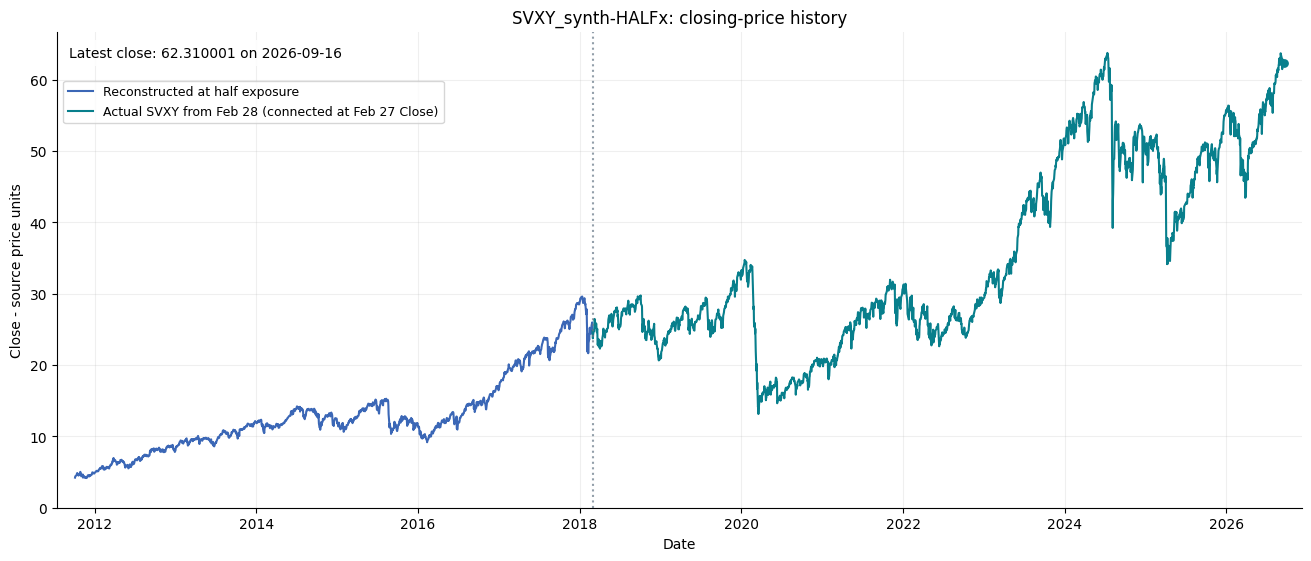

In [9]:
fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
ax.plot(halfx.loc[:LAST_ONEX].index, halfx.loc[:LAST_ONEX], color=SYNTH_COLOR,
        linewidth=1.5, label="Reconstructed at half exposure")
ax.plot(halfx.loc[LAST_ONEX:].index, halfx.loc[LAST_ONEX:], color="#087F8C",
        linewidth=1.5, label="Actual SVXY from Feb 28 (connected at Feb 27 Close)")
last_date, last_close = halfx.index[-1], float(halfx.iloc[-1])
ax.scatter([last_date], [last_close], color="#087F8C", s=28, zorder=3)
ax.axvline(FIRST_HALFX, color=ACTUAL_COLOR, linestyle=":", alpha=0.7)
ax.set(title="SVXY_synth-HALFx: closing-price history", xlabel="Date", ylabel="Close - source price units")
ax.set_ylim(bottom=0)
ax.margins(x=0.015, y=0.08)
ax.text(0.01, 0.97, f"Latest close: {last_close:.6f} on {last_date:%Y-%m-%d}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85})
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.91), fontsize=9)
plt.show()

### 6. Save the final file to disk

Now we save **SVXY_synth-HALFx.csv** in the same working directory. The file has one row per actual SVXY date, in ascending order, and five columns: `Date`, `Open`, `High`, `Low` and `Close`.

Running the notebook again updates this CSV. The calculations, checks and graphs remain inside the notebook. We also read the saved CSV back and verify that its OHLC from February 28 onward equal the original data.

In [10]:
csv_path = DATA_DIR / "SVXY_synth-HALFx.csv"
output = halfx_ohlc.copy()
output.index.name = "Date"
output.to_csv(csv_path, date_format="%Y-%m-%d", float_format="%.12f")

saved = pd.read_csv(csv_path, parse_dates=["Date"]).set_index("Date")
pd.testing.assert_index_equal(saved.index, output.index)
if saved.columns.tolist() != OHLC_COLUMNS:
    raise AssertionError("Unexpected output columns.")
np.testing.assert_allclose(saved, output, rtol=1e-12, atol=1e-10)
validate_ohlc(saved, "Saved SVXY_synth-HALFx")
pd.testing.assert_frame_equal(saved.loc[FIRST_HALFX:], actual_ohlc.loc[FIRST_HALFX:], check_exact=True)
for p in [SVXY_FILE, INDEX_FILE]:
    if sha256_file(p) != input_hashes[p.name]:
        raise AssertionError(f"Input file changed while the notebook was running: {p.name}")

print(f"Done: {len(saved):,} OHLC bars, {saved.index.min().date()} to {saved.index.max().date()}.")
print(f"Regression R² = {100*r_squared:.4f}%")
print(f"Backwards HALF event correction factor = {corr_f_backward:.12f}")
display(pd.concat([saved.head(3), saved.tail(3)]).round(6))

Done: 3,759 OHLC bars, 2011-10-04 to 2026-09-16.
Regression R² = 88.8669%
Backwards HALF event correction factor = 0.526096761969


,Open,High,Low,Close
Date,,,,
2011-10-04,4.085055,4.220051,4.075228,4.220051
2011-10-05,4.291722,4.397474,4.287712,4.384944
2011-10-06,4.386876,4.430349,4.356445,4.430349
2026-09-14,61.930000,62.849998,61.869999,62.610001
2026-09-15,62.750000,62.849998,62.169998,62.580002
2026-09-16,62.950001,63.020000,61.520000,62.310001


### Data and reference links:

- [Investing.com - SPVIXSTR historical data](https://www.investing.com/indices/sp-500-vix-short-term-futures-tri-historical-data): manually downloaded input.
- [S&P DJI - S&P 500 VIX Short-Term Futures Index](https://www.spglobal.com/spdji/en/indices/indicators/sp-500-vix-short-term-index-mcap/): index identity and return versions.
- [S&P VIX Futures Indices Methodology](https://www.spglobal.com/spdji/en/documents/methodologies/methodology-sp-vix-futures-indices.pdf): rolling futures and return calculations.
- [ProShares announcement, February 26, 2018](https://www.sec.gov/Archives/edgar/data/1415311/000119312518059052/d503117dex991.htm): change effective at the close of February 27.
- [NYSE Arca filing, February 6, 2018](https://www.nyse.com/publicdocs/nyse/markets/nyse-arca/rule-filings/filings/2018/NYSEArca-2018-12.pdf): event-related market disruption.